In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bindingdb-for-dta/Ki_bind.tsv
/kaggle/input/bindingdb-for-dta/IC50_bind.tsv
/kaggle/input/bindingdb-for-dta/Kd_bind.tsv
/kaggle/input/bindingdb-for-dta/EC50_bind.tsv


In [2]:
def load_file(path, affinity_type):
    df = pd.read_csv(path, sep='\t')
    df = df[['smiles', 'target_seq', 'affinity']].dropna()
    df['AffinityType'] = affinity_type
    return df
    
df_ki = load_file('/kaggle/input/bindingdb-for-dta/Ki_bind.tsv', 'Ki')
df_ic50 = load_file('/kaggle/input/bindingdb-for-dta/IC50_bind.tsv', 'IC50')
df_kd = load_file('/kaggle/input/bindingdb-for-dta/Kd_bind.tsv', 'Kd')
df_ec50 = load_file('/kaggle/input/bindingdb-for-dta/EC50_bind.tsv', 'EC50')

In [3]:
df_ki.shape

(380365, 4)

In [4]:
df_ic50.shape

(1034575, 4)

In [5]:
df_kd.shape

(57002, 4)

In [6]:
df_ec50.shape

(163745, 4)

In [7]:
df_ki.head()

,smiles,target_seq,affinity,AffinityType
0,Cc1cn([C@H]2C[C@H](O)[C@@H](CO)O2)c(=O)[nH]c1=O,MSCINLPTVLPGSPSKTRGQIQVILGPMFSGKSTELMRRVRRFQIA...,6.698970,Ki
1,Cc1cn([C@H]2C[C@H](O)[C@@H](CO)O2)c(=O)[nH]c1=O,MAEQVALSRTQVCGILREELFQGDAFHQSDTHIFIIMGASGDLAKK...,4.812479,Ki
2,Cc1cn([C@H]2C[C@H](O)[C@@H](CO)O2)c(=O)[nH]c1=O,MAARRGALIVLEGVDRAGKSTQSRKLVEALCAAGHRAELLRFPERS...,3.744727,Ki
3,Cc1cn([C@H]2C[C@H](O)[C@@H](CO)O2)c(=O)[nH]c1=O,MPPYISAFQAAYIGIEVLIALVSVPGNVLVIWAVKVNQALRDATFC...,4.999957,Ki
4,Cc1cn([C@H]2C[C@H](O)[C@@H](CO)O2)c(=O)[nH]c1=O,MGSSVYITVELAIAVLAILGNVLVCWAVWINSNLQNVTNFFVVSLA...,4.999957,Ki


In [8]:
df_ki["affinity"].min()

np.float64(-4.9999999999999964)

In [9]:
df_ki["affinity"].max()

np.float64(14.522878745280336)

In [10]:
df_ki["affinity"].mean()

np.float64(6.822691891178195)


Processing Ki dataset with 380365 entries...
Found 711 invalid affinity values (≤ 0), removing...


/tmp/ipykernel_10/2899283594.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pValue'] = -np.log10(df['affinity'] * 1e-9)  # Convert from nM to M first


Original entries: 379654
Valid entries after cleaning: 379654
Strong binders (≤ 1000nM): 379654 (100.0%)
Weak binders (> 1000nM): 0 (0.0%)


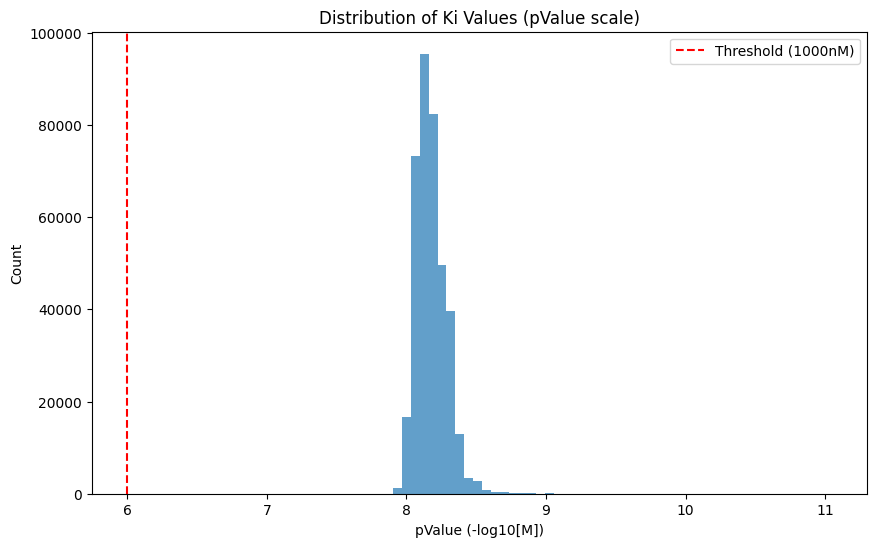


Processing IC50 dataset with 1034575 entries...
Found 306 invalid affinity values (≤ 0), removing...


/tmp/ipykernel_10/2899283594.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pValue'] = -np.log10(df['affinity'] * 1e-9)  # Convert from nM to M first


Original entries: 1034269
Valid entries after cleaning: 1034269
Strong binders (≤ 1000nM): 1034269 (100.0%)
Weak binders (> 1000nM): 0 (0.0%)


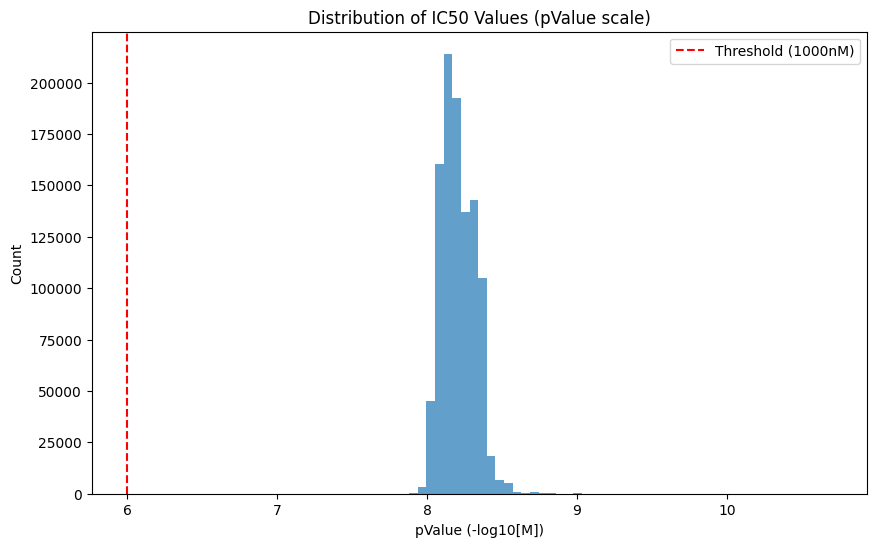


Processing Kd dataset with 57002 entries...
Found 7 invalid affinity values (≤ 0), removing...


/tmp/ipykernel_10/2899283594.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pValue'] = -np.log10(df['affinity'] * 1e-9)  # Convert from nM to M first


Original entries: 56995
Valid entries after cleaning: 56995
Strong binders (≤ 1000nM): 56995 (100.0%)
Weak binders (> 1000nM): 0 (0.0%)


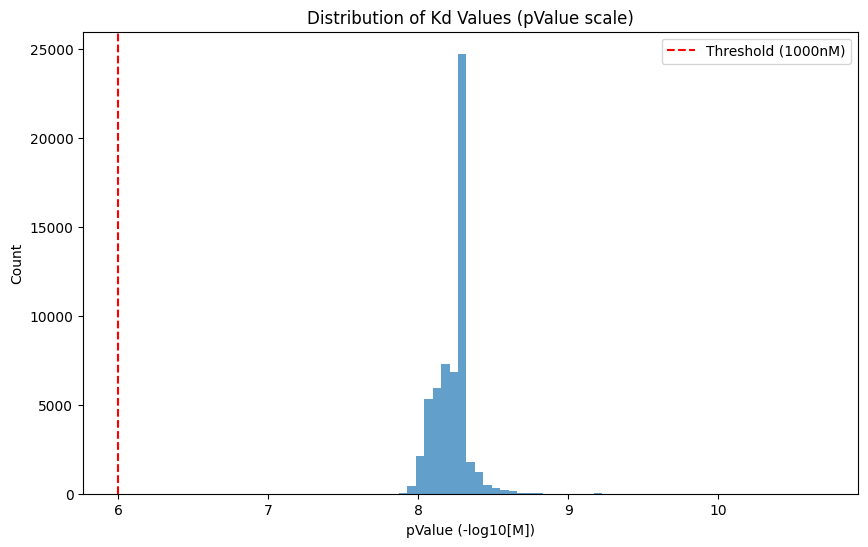


Processing EC50 dataset with 163745 entries...
Found 31 invalid affinity values (≤ 0), removing...


/tmp/ipykernel_10/2899283594.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pValue'] = -np.log10(df['affinity'] * 1e-9)  # Convert from nM to M first


Original entries: 163714
Valid entries after cleaning: 163714
Strong binders (≤ 1000nM): 163714 (100.0%)
Weak binders (> 1000nM): 0 (0.0%)


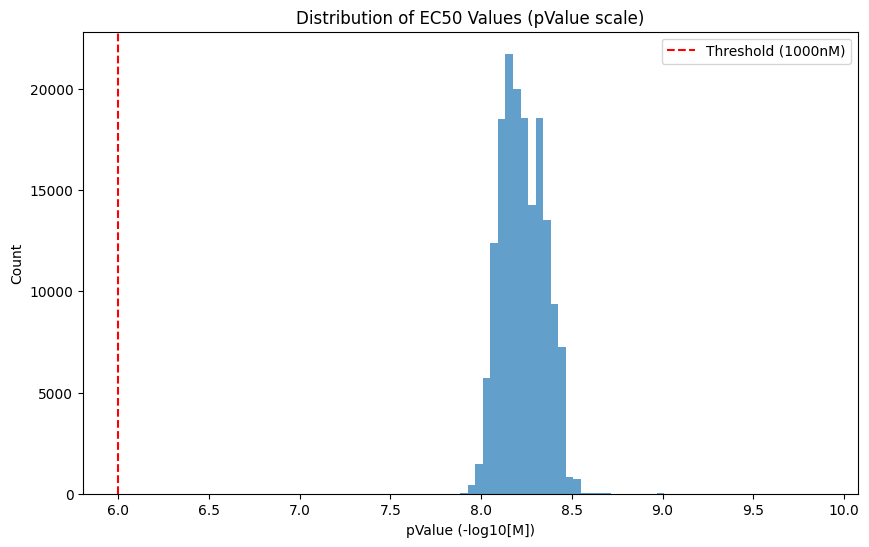


Final combined dataset has 1634632 entries
Distribution by affinity type:
affinity_type
IC50    1034269
Ki       379654
EC50     163714
Kd        56995
Name: count, dtype: int64


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def clean_and_process_affinity(df, affinity_type, threshold_nm=1000):
    """
    Clean and process affinity data:
    1. Remove bad values
    2. Convert to pValue notation
    3. Filter by activity threshold
    
    Parameters:
    -----------
    df : pandas DataFrame
        DataFrame containing affinity data
    affinity_type : str
        Type of affinity value ('Ki', 'IC50', etc.)
    threshold_nm : float
        Threshold in nM for filtering (default: 1000nM = 1μM, common activity cutoff)
    
    Returns:
    --------
    pandas DataFrame
        Cleaned and processed DataFrame
    """
    print(f"\nProcessing {affinity_type} dataset with {len(df)} entries...")
    
    # 1. Check for missing values
    missing_count = df['affinity'].isna().sum()
    if missing_count > 0:
        print(f"Found {missing_count} missing affinity values, removing...")
        df = df.dropna(subset=['affinity'])
    
    # 2. Check for invalid values (≤ 0)
    invalid_count = (df['affinity'] <= 0).sum()
    if invalid_count > 0:
        print(f"Found {invalid_count} invalid affinity values (≤ 0), removing...")
        df = df[df['affinity'] > 0]
    
    # 3. Convert to pValue (-log10)
    df['pValue'] = -np.log10(df['affinity'] * 1e-9)  # Convert from nM to M first
    
    # 4. Filter by threshold
    p_threshold = -np.log10(threshold_nm * 1e-9)
    weak_binders = df[df['pValue'] < p_threshold]
    strong_binders = df[df['pValue'] >= p_threshold]
    
    print(f"Original entries: {len(df)}")
    print(f"Valid entries after cleaning: {len(df)}")
    print(f"Strong binders (≤ {threshold_nm}nM): {len(strong_binders)} ({len(strong_binders)/len(df)*100:.1f}%)")
    print(f"Weak binders (> {threshold_nm}nM): {len(weak_binders)} ({len(weak_binders)/len(df)*100:.1f}%)")
    
    # 5. Display distribution
    plt.figure(figsize=(10, 6))
    plt.hist(df['pValue'], bins=50, alpha=0.7)
    plt.axvline(x=p_threshold, color='r', linestyle='--', label=f'Threshold ({threshold_nm}nM)')
    plt.title(f'Distribution of {affinity_type} Values (pValue scale)')
    plt.xlabel('pValue (-log10[M])')
    plt.ylabel('Count')
    plt.legend()
    plt.show()
    
    return strong_binders

# Process each dataset
cleaned_ki = clean_and_process_affinity(df_ki, 'Ki')
cleaned_ic50 = clean_and_process_affinity(df_ic50, 'IC50')
cleaned_kd = clean_and_process_affinity(df_kd, 'Kd')
cleaned_ec50 = clean_and_process_affinity(df_ec50, 'EC50')

# Combine if needed (optional)
all_cleaned = pd.concat([
    cleaned_ki.assign(affinity_type='Ki'),
    cleaned_ic50.assign(affinity_type='IC50'),
    cleaned_kd.assign(affinity_type='Kd'),
    cleaned_ec50.assign(affinity_type='EC50')
], ignore_index=True)

print(f"\nFinal combined dataset has {len(all_cleaned)} entries")
print(f"Distribution by affinity type:")
print(all_cleaned['affinity_type'].value_counts())

In [12]:
all_cleaned.shape

(1634632, 6)

In [13]:
all_cleaned.head(5)

,smiles,target_seq,affinity,AffinityType,pValue,affinity_type
0,Cc1cn([C@H]2C[C@H](O)[C@@H](CO)O2)c(=O)[nH]c1=O,MSCINLPTVLPGSPSKTRGQIQVILGPMFSGKSTELMRRVRRFQIA...,6.698970,Ki,8.173992,Ki
1,Cc1cn([C@H]2C[C@H](O)[C@@H](CO)O2)c(=O)[nH]c1=O,MAEQVALSRTQVCGILREELFQGDAFHQSDTHIFIIMGASGDLAKK...,4.812479,Ki,8.317631,Ki
2,Cc1cn([C@H]2C[C@H](O)[C@@H](CO)O2)c(=O)[nH]c1=O,MAARRGALIVLEGVDRAGKSTQSRKLVEALCAAGHRAELLRFPERS...,3.744727,Ki,8.426580,Ki
3,Cc1cn([C@H]2C[C@H](O)[C@@H](CO)O2)c(=O)[nH]c1=O,MPPYISAFQAAYIGIEVLIALVSVPGNVLVIWAVKVNQALRDATFC...,4.999957,Ki,8.301034,Ki
4,Cc1cn([C@H]2C[C@H](O)[C@@H](CO)O2)c(=O)[nH]c1=O,MGSSVYITVELAIAVLAILGNVLVCWAVWINSNLQNVTNFFVVSLA...,4.999957,Ki,8.301034,Ki


In [14]:
# First, let's check how many duplicated SMILES-target pairs we have
duplicate_count = all_cleaned.duplicated(subset=['smiles', 'target_seq'], keep=False).sum()
unique_pairs = all_cleaned[['smiles', 'target_seq']].drop_duplicates()

print(f"Total rows in dataset: {len(all_cleaned)}")
print(f"Unique SMILES-target pairs: {len(unique_pairs)}")
print(f"Duplicate rows: {duplicate_count} ({duplicate_count/len(all_cleaned)*100:.2f}%)")

# Check how many measurements exist for the most duplicated pairs
dup_counts = all_cleaned.groupby(['smiles', 'target_seq']).size().sort_values(ascending=False)
print("\nTop 5 most duplicated SMILES-target pairs:")
print(dup_counts.head(5))

# Check distribution of duplicates by affinity type
print("\nDuplicate distribution by affinity type:")
print(all_cleaned[all_cleaned.duplicated(subset=['smiles', 'target_seq'], keep=False)]
      ['affinity_type'].value_counts())

Total rows in dataset: 1634632
Unique SMILES-target pairs: 1562034
Duplicate rows: 141663 (8.67%)

Top 5 most duplicated SMILES-target pairs:
smiles                                                                 target_seq                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         
CN1CCC[C@H](C1)NC(=O)c1sc2nccc3n(-c4ccc(Oc5ccccc5)cc4C)c(=O)[nH]c1c23  MAAVILESIFLKRSQQKKKTSPLNFKKRLFLLTVHKLSYYEYDFERGRRGSKKGSI

In [15]:
def clean_duplicate_pairs(df, method='strongest', min_pvalue_threshold=5.0):
    """
    Remove duplicate SMILES-target pairs using various strategies
    
    Parameters:
    -----------
    df : pandas DataFrame
        Input DataFrame with SMILES-target pairs
    method : str
        Method to use: 'strongest', 'priority', 'aggregate', or 'all'
    min_pvalue_threshold : float
        Minimum pValue threshold (default 5.0 = 10μM)
        
    Returns:
    --------
    pandas DataFrame
        Cleaned DataFrame without duplicates
    """
    print(f"\nCleaning duplicate SMILES-target pairs using {method} method...")
    print(f"Initial dataset: {len(df)} rows")
    
    # First filter out very weak binders
    df = df[df['pValue'] >= min_pvalue_threshold].copy()
    print(f"After filtering weak binders: {len(df)} rows")
    
    # Define priority if needed
    if method in ['priority', 'all']:
        affinity_priority = {'Ki': 1, 'Kd': 2, 'IC50': 3, 'EC50': 4}
        df['priority'] = df['affinity_type'].map(affinity_priority)
    
    # Apply the selected method
    if method == 'strongest':
        # Keep strongest binding
        result = (df.sort_values('pValue', ascending=False)
                   .drop_duplicates(subset=['smiles', 'target_seq']))
        
    elif method == 'priority':
        # Prioritize by affinity type, then by strength
        result = (df.sort_values(['priority', 'pValue'], ascending=[True, False])
                   .drop_duplicates(subset=['smiles', 'target_seq']))
        
    elif method == 'aggregate':
        # Create aggregated dataset
        result = df.groupby(['smiles', 'target_seq']).agg(
            affinity_count=('affinity', 'count'),
            affinity_mean=('affinity', 'mean'),
            affinity_min=('affinity', 'min'),
            affinity_max=('affinity', 'max'),
            pValue_mean=('pValue', 'mean'),
            pValue_min=('pValue', 'min'),
            pValue_max=('pValue', 'max'),
            affinity_types=('affinity_type', lambda x: ', '.join(sorted(set(x))))
        ).reset_index()
        
    elif method == 'all':
        # Most comprehensive approach
        
        # First get aggregate statistics
        agg_stats = df.groupby(['smiles', 'target_seq']).agg(
            count=('pValue', 'count'),
            pValue_std=('pValue', 'std'),
            pValue_mean=('pValue', 'mean'),
            type_count=('affinity_type', lambda x: len(set(x)))
        ).reset_index()
        
        # For pairs with low variance (consistent measurements), use strongest binding
        consistent_pairs = set(agg_stats[agg_stats['pValue_std'] < 0.5][['smiles', 'target_seq']].itertuples(index=False))
        
        # For pairs with high variance or multiple types, use priority method
        result = pd.DataFrame()
        
        for (smiles, target_seq), group in df.groupby(['smiles', 'target_seq']):
            if (smiles, target_seq) in consistent_pairs and len(group) > 1:
                # For consistent measurements, take strongest
                result = pd.concat([result, group.sort_values('pValue', ascending=False).iloc[:1]])
            else:
                # For inconsistent measurements, use priority then strength
                result = pd.concat([
                    result, 
                    group.sort_values(['priority', 'pValue'], ascending=[True, False]).iloc[:1]
                ])
    else:
        raise ValueError(f"Unknown method: {method}")
    
    print(f"Final cleaned dataset: {len(result)} rows")
    return result


cleaned_strongest = clean_duplicate_pairs(all_cleaned, method='strongest')
# cleaned_priority = clean_duplicate_pairs(all_cleaned, method='priority')
#cleaned_aggregate = clean_duplicate_pairs(all_cleaned, method='aggregate')
# cleaned_comprehensive = clean_duplicate_pairs(all_cleaned, method='all')


Cleaning duplicate SMILES-target pairs using strongest method...
Initial dataset: 1634632 rows
After filtering weak binders: 1634632 rows
Final cleaned dataset: 1562034 rows


In [16]:
#cleaned_strongest.to_csv('cleaned_affinity_data_no_duplicates.csv', index=False)

# Check final distribution of affinity types
print("\nDistribution of affinity types in final dataset:")
print(cleaned_strongest['affinity_type'].value_counts())


Distribution of affinity types in final dataset:
affinity_type
IC50    1011206
Ki       348406
EC50     150614
Kd        51808
Name: count, dtype: int64


In [17]:
!pip install rdkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 10.3 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [18]:
from rdkit import Chem
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import concurrent.futures

def check_smiles_batch(smiles_batch):
    """Process a batch of SMILES validation in parallel"""
    results = []
    for smiles in smiles_batch:
        try:
            mol = Chem.MolFromSmiles(smiles)
            results.append(mol is not None)
        except:
            results.append(False)
    return results

def filter_invalid_smiles_parallel(df, smiles_column='smiles', batch_size=10000, n_workers=8):
    """Filter invalid SMILES using parallel processing"""
    print(f"Validating {len(df)} SMILES entries in parallel...")
    
    # Get all SMILES
    all_smiles = df[smiles_column].values
    
    # Split into batches
    batches = [all_smiles[i:i+batch_size] for i in range(0, len(all_smiles), batch_size)]
    print(f"Processing {len(batches)} batches with {n_workers} workers")
    
    # Process in parallel
    valid_flags = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = [executor.submit(check_smiles_batch, batch) for batch in batches]
        
        for future in tqdm(concurrent.futures.as_completed(futures), 
                          total=len(futures), 
                          desc="Validating SMILES"):
            batch_results = future.result()
            valid_flags.extend(batch_results)
    
    # Convert to numpy array instead of Series to avoid index alignment issues
    valid_mask = np.array(valid_flags)
    
    # Apply the mask
    valid_df = df[valid_mask].copy().reset_index(drop=True)
    invalid_df = df[~valid_mask].copy().reset_index(drop=True)
    
    # Print results
    print(f"Original SMILES count: {len(df)}")
    print(f"Valid SMILES count: {len(valid_df)} ({len(valid_df)/len(df)*100:.2f}%)")
    print(f"Invalid SMILES count: {len(invalid_df)} ({len(invalid_df)/len(df)*100:.2f}%)")
    
    return valid_df, invalid_df

# Apply the parallel version
valid_df, invalid_df = filter_invalid_smiles_parallel(cleaned_strongest)

/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Validating 1562034 SMILES entries in parallel...
Processing 157 batches with 8 workers


[17:00:57] Explicit valence for atom # 1 N, 4, is greater than permitted
[17:00:57] Explicit valence for atom # 1 N, 4, is greater than permitted
Validating SMILES:   0%|          | 0/157 [00:00<?, ?it/s][17:01:00] Can't kekulize mol.  Unkekulized atoms: 10 12 13 14 15
[17:01:00] Explicit valence for atom # 1 N, 4, is greater than permitted
[17:01:00] Explicit valence for atom # 1 N, 4, is greater than permitted
[17:01:01] Explicit valence for atom # 0 N, 4, is greater than permitted
[17:01:01] Can't kekulize mol.  Unkekulized atoms: 9 11 12 13 14
[17:01:02] Can't kekulize mol.  Unkekulized atoms: 11 13 14 15 16
[17:01:02] Can't kekulize mol.  Unkekulized atoms: 7 8 9 10 11 12 13
[17:01:02] Explicit valence for atom # 5 N, 4, is greater than permitted
[17:01:02] Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 21
[17:01:03] Explicit valence for atom # 41 N, 4, is greater than permitted
[17:01:03] Can't kekulize mol.  Unkekulized atoms: 10 12 13 14 15
[17:01:03] Can't kekulize mol.  

Original SMILES count: 1562034
Valid SMILES count: 1560567 (99.91%)
Invalid SMILES count: 1467 (0.09%)


Calculating drug-like properties in parallel...
Processing 915732 unique molecules
Created 916 batches with 1000 molecules per batch


Processing batches:   0%|          | 0/916 [00:00<?, ?it/s][17:07:15] Explicit valence for atom # 1 N, 4, is greater than permitted
[17:07:21] Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 20 21 22 23 25
[17:07:52] Explicit valence for atom # 1 N, 4, is greater than permitted
[17:07:52] Explicit valence for atom # 1 N, 4, is greater than permitted
[17:07:58] Explicit valence for atom # 30 N, 4, is greater than permitted
[17:07:59] Explicit valence for atom # 16 N, 4, is greater than permitted
[17:08:05] Explicit valence for atom # 0 N, 4, is greater than permitted
[17:08:10] Explicit valence for atom # 31 N, 4, is greater than permitted
Processing batches:   2%|▏         | 15/916 [00:58<06:07,  2.45it/s]  [17:09:02] Explicit valence for atom # 0 N, 4, is greater than permitted
[17:09:05] Explicit valence for atom # 41 N, 4, is greater than permitted
Processing batches:   3%|▎         | 32/916 [01:58<07:53,  1.87it/s]  [17:09:23] Explicit valence for atom # 1 N, 4, is greater than

Successfully processed 915187 unique molecules in 3932.0 seconds
Processing speed: 232.8 molecules/second
Failed to process 545 molecules (0.06%)

=== Drug Property Statistics ===
                QED         MolWt          LogP          TPSA           HBD  \
count  1.559885e+06  1.559885e+06  1.559885e+06  1.559885e+06  1.559885e+06   
mean   5.098921e-01  4.519271e+02  3.541265e+00  9.767481e+01  2.119128e+00   
std    2.133450e-01  2.390619e+02  2.238918e+00  1.002751e+02  3.548077e+00   
min    2.686260e-03  6.941000e+00 -7.474690e+01  0.000000e+00  0.000000e+00   
25%    3.579822e-01  3.562120e+02  2.592400e+00  6.182000e+01  1.000000e+00   
50%    5.152481e-01  4.264100e+02  3.662360e+00  8.483000e+01  2.000000e+00   
75%    6.772539e-01  4.985380e+02  4.730100e+00  1.098600e+02  2.000000e+00   
max    9.483293e-01  1.254632e+04  1.805172e+02  4.638220e+03  9.800000e+01   

                HBA      RotBonds  Lipinski_Violations  
count  1.559885e+06  1.559885e+06         1.559885e

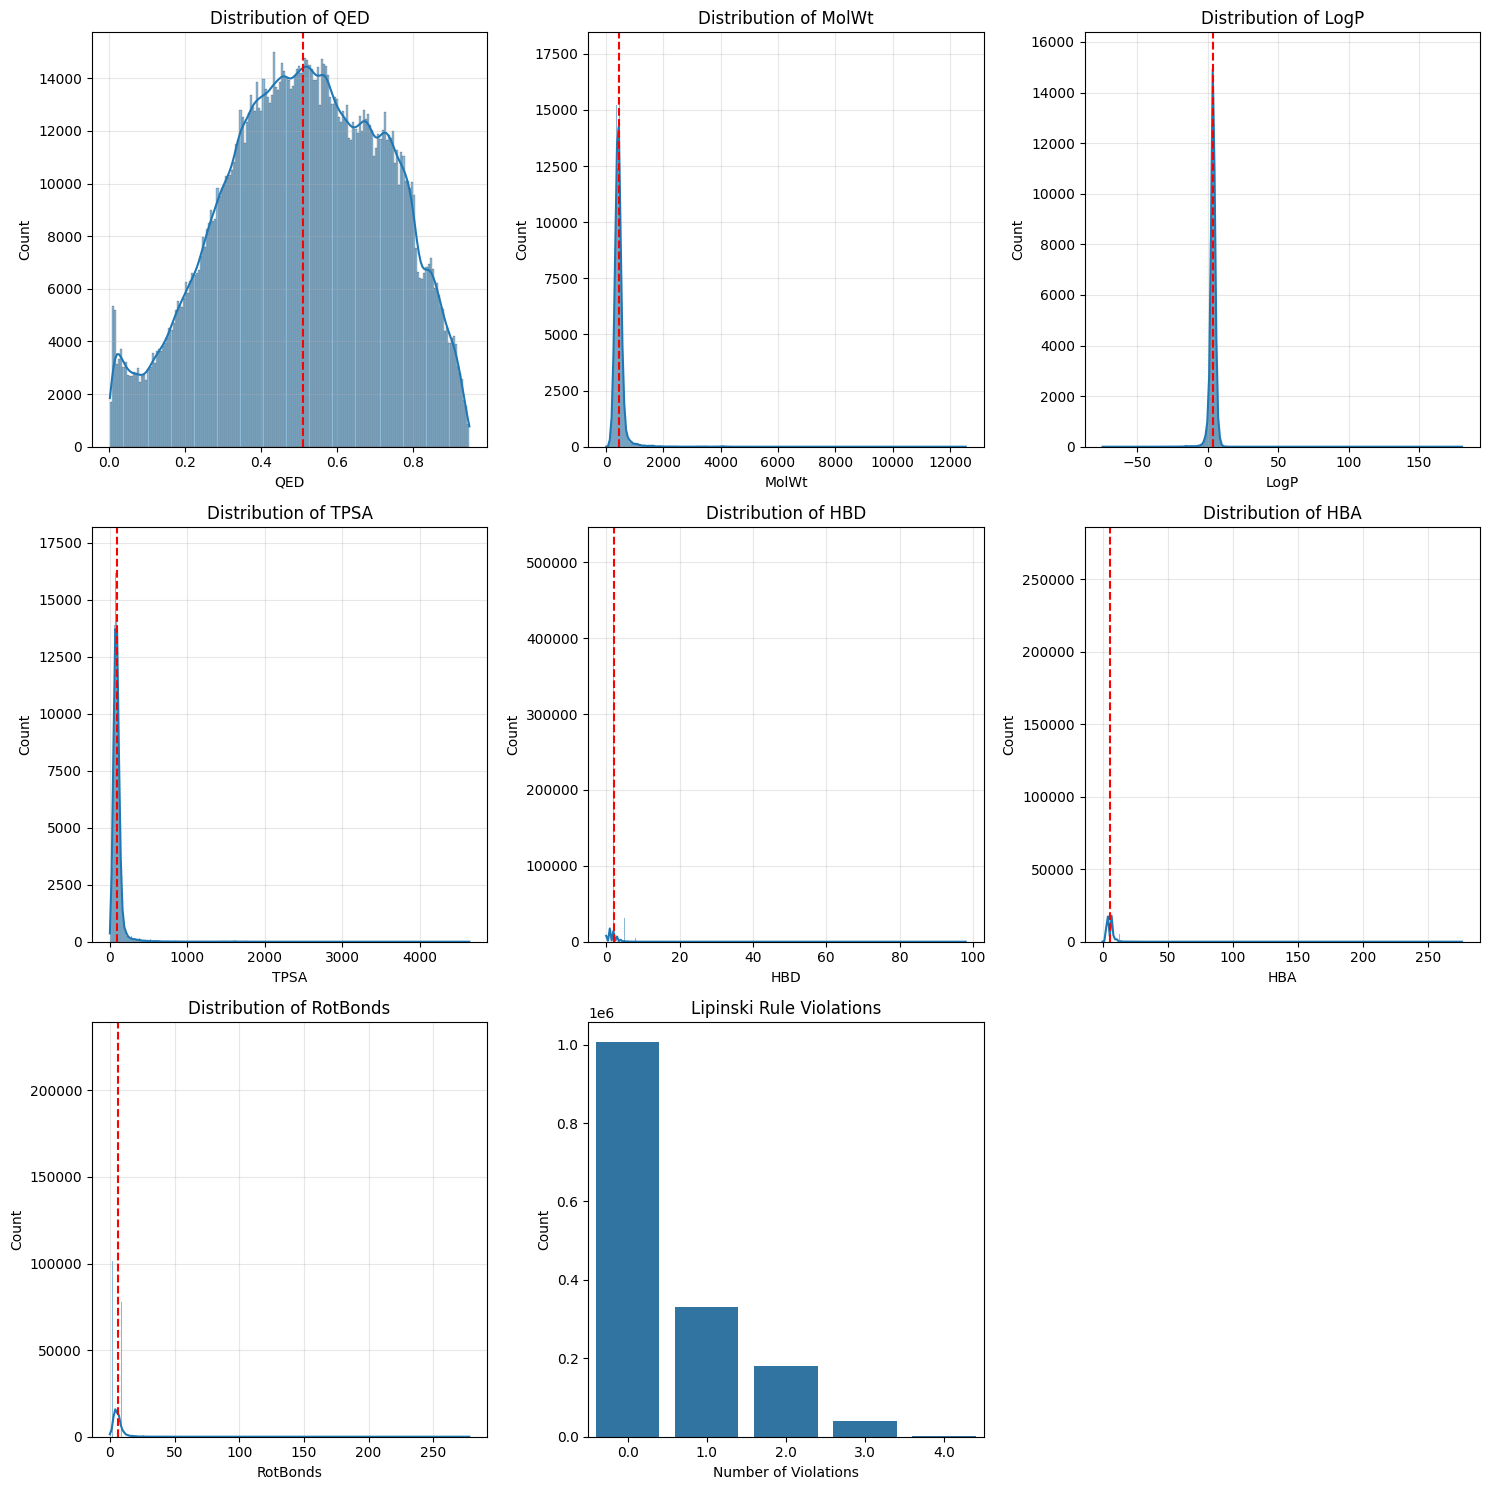


=== Average Properties by Affinity Type ===
                    QED       MolWt      LogP        TPSA       HBD       HBA  \
affinity_type                                                                   
EC50           0.514813  472.455928  3.524855  107.388750  2.422185  6.061425   
IC50           0.507886  447.407963  3.652575   95.435739  1.998694  5.897199   
Kd             0.457427  496.934154  3.509996  114.486128  2.691785  6.931325   
Ki             0.521394  449.465991  3.230067   97.469992  2.252315  5.632357   

               RotBonds  Lipinski_Violations  
affinity_type                                 
EC50           7.667054             0.590665  
IC50           6.234657             0.507648  
Kd             7.314335             0.730785  
Ki             6.860483             0.511237  


In [19]:
from rdkit import Chem
from rdkit.Chem import Descriptors, QED, Lipinski
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import concurrent.futures
import time
from tqdm.auto import tqdm

def calculate_batch_properties(smiles_batch):
    """Process a batch of SMILES in parallel"""
    results = []
    for smiles in smiles_batch:
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol:
                # Calculate all properties at once
                result = {
                    'smiles': smiles,
                    'QED': QED.qed(mol),
                    'MolWt': Descriptors.MolWt(mol),
                    'LogP': Descriptors.MolLogP(mol),
                    'TPSA': Descriptors.TPSA(mol),
                    'HBD': Descriptors.NumHDonors(mol),
                    'HBA': Descriptors.NumHAcceptors(mol),
                    'RotBonds': Descriptors.NumRotatableBonds(mol),
                    'Lipinski_Violations': (Descriptors.NumHDonors(mol) > 5) + 
                                          (Descriptors.NumHAcceptors(mol) > 10) + 
                                          (Descriptors.MolWt(mol) > 500) + 
                                          (Descriptors.MolLogP(mol) > 5)
                }
                results.append(result)
        except:
            pass
    return results

def calculate_drug_properties_parallel(df, batch_size=1000, n_workers=16):
    """Calculate drug properties in parallel using a thread pool"""
    print("Calculating drug-like properties in parallel...")
    start_time = time.time()
    
    # Create list of unique SMILES to process
    all_smiles = df['smiles'].unique()
    print(f"Processing {len(all_smiles)} unique molecules")
    
    # Split into batches
    batches = [all_smiles[i:i+batch_size] for i in range(0, len(all_smiles), batch_size)]
    print(f"Created {len(batches)} batches with {batch_size} molecules per batch")
    
    # Process batches in parallel
    results = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = [executor.submit(calculate_batch_properties, batch) for batch in batches]
        
        # Process results as they complete
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures), 
                          desc="Processing batches"):
            batch_results = future.result()
            results.extend(batch_results)
    
    # Convert results to DataFrame
    props_df = pd.DataFrame(results)
    
    # Create mapping dictionary for fast lookups
    props_dict = dict(zip(props_df['smiles'], props_df.to_dict('records')))
    
    # Apply properties to original DataFrame (much faster than iterating)
    result_df = df.copy()
    
    # Initialize property columns
    for prop in ['QED', 'MolWt', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Lipinski_Violations']:
        result_df[prop] = None
    
    # Apply the properties using vectorized operations
    def apply_props(row):
        props = props_dict.get(row['smiles'])
        if props:
            for prop in ['QED', 'MolWt', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Lipinski_Violations']:
                row[prop] = props[prop]
        return row
    
    # Apply the properties
    result_df = result_df.apply(apply_props, axis=1)
    
    # Report performance
    elapsed = time.time() - start_time
    processed_count = len(props_df)
    failed_count = len(all_smiles) - processed_count
    
    print(f"Successfully processed {processed_count} unique molecules in {elapsed:.1f} seconds")
    print(f"Processing speed: {processed_count/elapsed:.1f} molecules/second")
    print(f"Failed to process {failed_count} molecules ({failed_count/len(all_smiles)*100:.2f}%)")
    
    return result_df

# Use the accelerated function
df_with_props = calculate_drug_properties_parallel(
    valid_df, 
    batch_size=1000,  # Adjust batch size based on memory
    n_workers=16      # Adjust based on CPU cores available
)

# Calculate summary statistics
props = ['QED', 'MolWt', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Lipinski_Violations']
summary = df_with_props[props].describe()

print("\n=== Drug Property Statistics ===")
print(summary)


# Plot distributions
plt.figure(figsize=(15, 15))

for i, prop in enumerate(props[:7], 1):  # Skip boolean Lipinski violations
    plt.subplot(3, 3, i)
    sns.histplot(df_with_props[prop].dropna(), kde=True)
    plt.title(f'Distribution of {prop}')
    plt.axvline(df_with_props[prop].mean(), color='r', linestyle='--')
    plt.grid(True, alpha=0.3)

# Additional plot for Lipinski violations
plt.subplot(3, 3, 8)
violation_counts = df_with_props['Lipinski_Violations'].value_counts()
sns.barplot(x=violation_counts.index.astype(str), y=violation_counts.values)
plt.title('Lipinski Rule Violations')
plt.xlabel('Number of Violations')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Group properties by affinity type
affinity_props = df_with_props.groupby('affinity_type')[props].mean()

print("\n=== Average Properties by Affinity Type ===")
print(affinity_props)

# Save the enriched dataset
df_with_props.to_csv('bindingdb_with_properties.csv', index=False)

In [1]:
import pandas as pd

df=pd.read_csv(r"C:\Users\kani1\OneDrive\Desktop\gdg_hackathon_25\MolGenX-api\MolGenX-backend\data\processed_cleaned_bindingDB.csv")
df.shape

(1560567, 14)

In [2]:
df.head(5)

,smiles,target_seq,affinity,AffinityType,pValue,affinity_type,QED,MolWt,LogP,TPSA,HBD,HBA,RotBonds,Lipinski_Violations
0,CN(Cc1cccc(F)c1)C(=O)c1cccn1C,MENQEKASIAGHMFDVVVIGGGISGLSAAKLLTEYGVSVLVLEARD...,0.009,Ki,11.045757,Ki,0.816207,246.285,2.43640,25.24,0.0,2.0,3.0,0.0
1,CC[C@H](C)[C@@H]1NC(=O)[C@@H](Cc2ccc(CC)cc2)NC...,MEGTPAANWSVELDLGSGVPPGEEGNRTAGPPQRNEALARVEVAVL...,0.020,Kd,10.698970,Kd,0.066489,1019.262,-2.75180,379.30,11.0,14.0,18.0,3.0
2,COc1ccccc1Oc1ccccc1CN1CCC2(CC1)CCN(CC2)C(=O)c1...,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,0.020,IC50,10.698970,IC50,0.322493,583.512,7.01090,79.31,1.0,5.0,7.0,2.0
3,COC(=O)CCC1C(=O)c2c(C1=O)c1cc(Br)ccc1nc2C,MENTENSVDSKSIKNLEPKIIHGSESMDSGISLDNSYKMDYPEMGL...,0.033,IC50,10.481486,IC50,0.607459,376.206,3.25412,73.33,0.0,5.0,3.0,0.0
4,CN(C)CCCNCc1ccc2nc3c(ccc4cc5cc(CNCCCN(C)C)ccc5...,MPRAPRCRAVRSLLRSHYREVLPLATFVRRLGPQGWRLVQRGDPAA...,0.040,IC50,10.397940,IC50,0.137743,508.714,5.17200,56.32,2.0,6.0,12.0,2.0


In [4]:
# Filter molecules with QED > 0.5 and MolWt < 600
filtered_df = df[(df['QED'] > 0.5) & (df['MolWt'] < 600)].reset_index(drop=True)

# Display shape and summary
print(f"Original dataset: {len(df)} molecules")
print(f"Filtered dataset: {len(filtered_df)} molecules")
print(f"Retained {len(filtered_df)/len(df)*100:.1f}% of molecules")

# Display basic statistics for the filtered set
filtered_summary = filtered_df[['QED', 'MolWt']].describe()
print("\nFiltered Dataset Statistics:")
print(filtered_summary)



Original dataset: 1560567 molecules
Filtered dataset: 819533 molecules
Retained 52.5% of molecules

Filtered Dataset Statistics:
                 QED          MolWt
count  819533.000000  819533.000000
mean        0.677541     366.534617
std         0.113774      75.353059
min         0.500002      74.123000
25%         0.578883     317.385000
50%         0.668703     371.387000
75%         0.763952     419.978000
max         0.948329     599.698000


In [5]:

filtered_df.to_csv('high_qed_optimal_weight_compounds.csv', index=False)